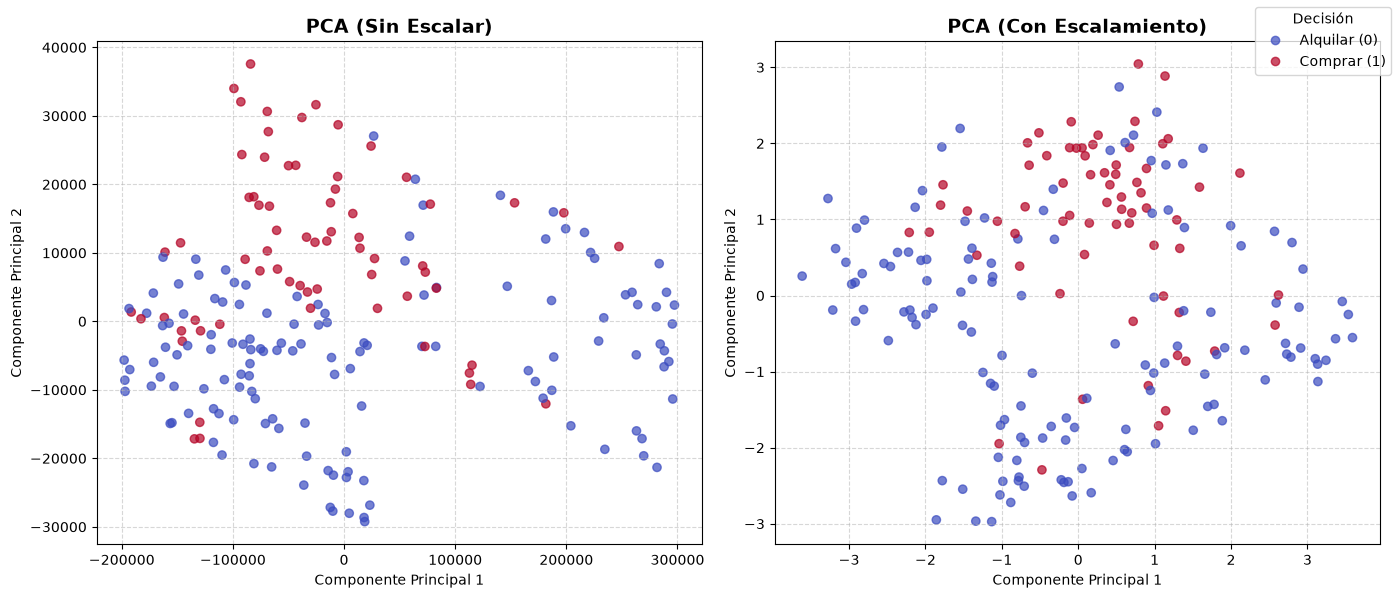

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import numpy as np

# 1. Cargar Datos
df_ca = pd.read_csv('comprar_alquilar.csv')

# Separar características (X) y la etiqueta 'comprar' (y) para colorear
X_ca = df_ca.drop(columns=['comprar'])
y_ca = df_ca['comprar']

# 2. PCA SIN ESCALAR
pca_sin_escalar = PCA(n_components=2)
X_pca_sin = pca_sin_escalar.fit_transform(X_ca)

# 3. ESCALAMIENTO
scaler_ca = StandardScaler()
X_ca_scaled = scaler_ca.fit_transform(X_ca)

# 4. PCA CON ESCALAMIENTO
pca_con_escalar = PCA(n_components=2)
X_pca_con = pca_con_escalar.fit_transform(X_ca_scaled)

# 5. GRAFICAR COMPARACIÓN
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Gráfica 1: Sin escalar
scatter1 = ax1.scatter(X_pca_sin[:, 0], X_pca_sin[:, 1], c=y_ca, cmap='coolwarm', alpha=0.7)
ax1.set_title('PCA (Sin Escalar)', fontsize=14, fontweight='bold')
ax1.set_xlabel('Componente Principal 1')
ax1.set_ylabel('Componente Principal 2')
ax1.grid(True, linestyle='--', alpha=0.5)

# Gráfica 2: Con escalamiento
scatter2 = ax2.scatter(X_pca_con[:, 0], X_pca_con[:, 1], c=y_ca, cmap='coolwarm', alpha=0.7)
ax2.set_title('PCA (Con Escalamiento)', fontsize=14, fontweight='bold')
ax2.set_xlabel('Componente Principal 1')
ax2.set_ylabel('Componente Principal 2')
ax2.grid(True, linestyle='--', alpha=0.5)

# Añadir leyenda
handles, labels = scatter2.legend_elements()
fig.legend(handles, ['Alquilar (0)', 'Comprar (1)'], loc='upper right', title="Decisión")
plt.tight_layout()
plt.show()

Varianza explicada por 2 componentes: 53.21%
Varianza explicada por 3 componentes: 64.92%


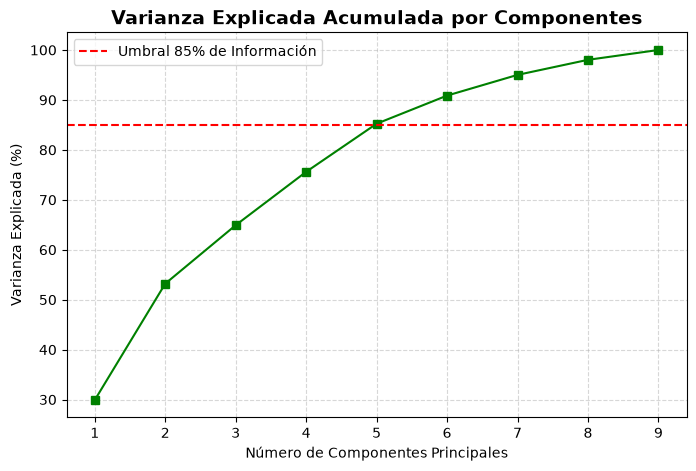

In [2]:
# 6. Analizar la Varianza para justificar cuántos componentes elegir
# Hacemos un PCA con el mismo número de componentes que variables originales
pca_total = PCA()
pca_total.fit(X_ca_scaled)

# Calcular varianza acumulada
varianza_acumulada = np.cumsum(pca_total.explained_variance_ratio_) * 100

print(f"Varianza explicada por 2 componentes: {varianza_acumulada[1]:.2f}%")
print(f"Varianza explicada por 3 componentes: {varianza_acumulada[2]:.2f}%")

# Gráfica de la Varianza Acumulada
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(varianza_acumulada) + 1), varianza_acumulada, marker='s', color='green')
plt.axhline(y=85, color='r', linestyle='--', label='Umbral 85% de Información')
plt.title('Varianza Explicada Acumulada por Componentes', fontsize=14, fontweight='bold')
plt.xlabel('Número de Componentes Principales')
plt.ylabel('Varianza Explicada (%)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()